Lab 21.1 – PCA
Goal: Apply PCA to the 70k‑image MNIST digits (28×28 → 784D), visualize variance explained, project to 2D/50D, reconstruct images, and (optionally) see how PCA affects a simple classifier.

In [2]:
# pip install scikit-learn matplotlib seaborn numpy
import numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA, IncrementalPCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
sns.set_theme(style='whitegrid', context='notebook')
np.random.seed(0)

1) Load MNIST (70,000 samples, 784 features)

In [3]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X = mnist.data.astype(np.float32)  # shape (70000, 784)
y = mnist.target.astype(int)
X.shape, y.shape

((70000, 784), (70000,))

MNIST pixel values are 0–255. Center/scale (per‑feature) before PCA:

In [4]:
scaler = StandardScaler(with_mean=True, with_std=True)  # PCA needs centering
X_std = scaler.fit_transform(X)

2) Train/test split (for optional classifier)

In [5]:
Xtr, Xte, ytr, yte = train_test_split(X_std, y, test_size=0.2, random_state=42, stratify=y)

3) Fit PCA and inspect explained variance

In [6]:
pca = PCA(n_components=0.99, svd_solver='full', random_state=0)  # keep 99% variance
pca.fit(Xtr)
print("Components for 99% variance:", pca.n_components_)

Components for 99% variance: 539


Plot explained variance ratio and its cumulative:

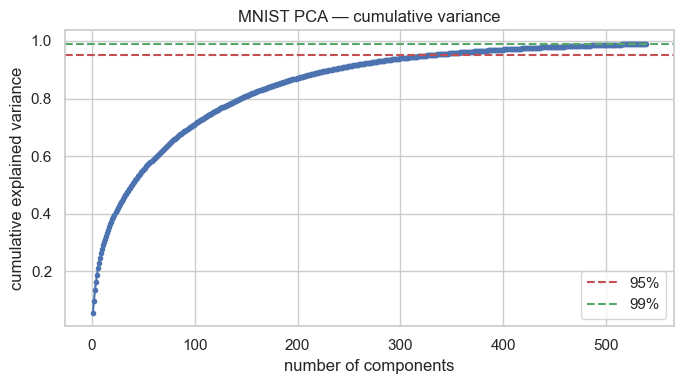

In [7]:
plt.figure(figsize=(7,4))
plt.plot(np.arange(1, len(pca.explained_variance_ratio_)+1),
         np.cumsum(pca.explained_variance_ratio_), marker='.')
plt.axhline(0.95, color='r', ls='--', label='95%')
plt.axhline(0.99, color='g', ls='--', label='99%')
plt.xlabel('number of components'); plt.ylabel('cumulative explained variance')
plt.title('MNIST PCA — cumulative variance'); plt.legend(); plt.tight_layout(); plt.show()

4) Project to 2D for visualization

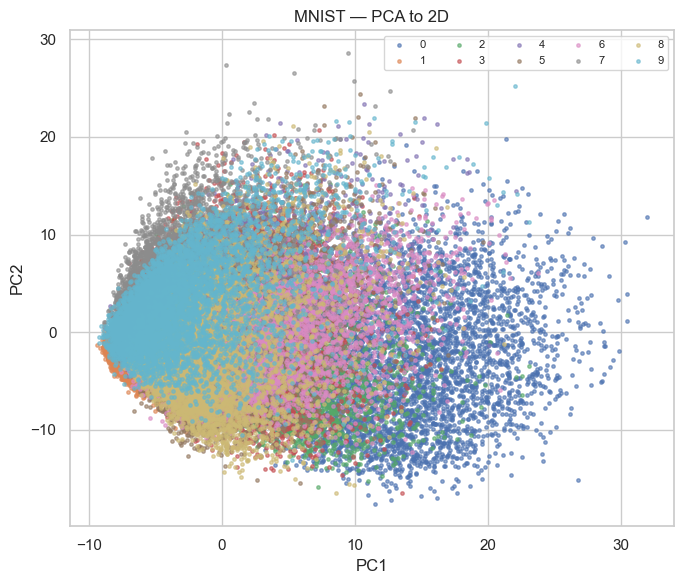

In [8]:
pca2 = PCA(n_components=2, random_state=0).fit(Xtr)
Ztr2 = pca2.transform(Xtr)
Zte2 = pca2.transform(Xte)

plt.figure(figsize=(7,6))
for d in range(10):
    idx = (ytr == d)
    plt.scatter(Ztr2[idx,0], Ztr2[idx,1], s=6, alpha=0.6, label=str(d))
plt.title('MNIST — PCA to 2D'); plt.xlabel('PC1'); plt.ylabel('PC2'); plt.legend(ncol=5, fontsize=8)
plt.tight_layout(); plt.show()

Observation: Classes overlap in 2D; PCA preserves global variance, not necessarily class separation.

5) Reduce to k=50 (common sweet spot) and reconstruct images

In [9]:
k = 50
pca50 = PCA(n_components=k, random_state=0).fit(Xtr)
Xte_50 = pca50.inverse_transform(pca50.transform(Xte))   # reconstructed (standardized space)
# Unscale back to pixel space 0..255-ish
Xte_50_px = scaler.inverse_transform(Xte_50)
Xte_px     = scaler.inverse_transform(Xte)               # originals

Visualize original vs reconstruction (10 random digits):

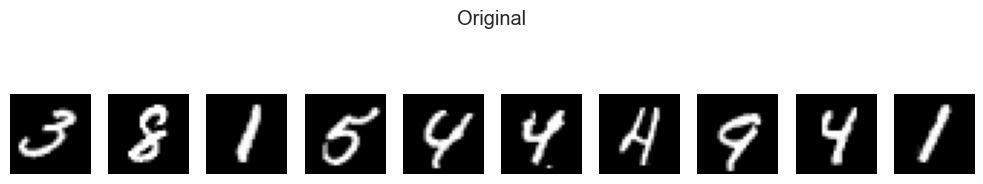

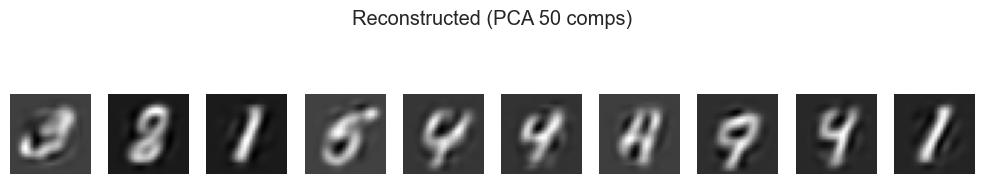

In [10]:
def show_grid(images, n=10, title=''):
    plt.figure(figsize=(10,2.2))
    for i in range(n):
        ax = plt.subplot(1, n, i+1)
        plt.imshow(images[i].reshape(28,28), cmap='gray')
        plt.axis('off')
    plt.suptitle(title); plt.tight_layout(); plt.show()

perm = np.random.permutation(len(Xte_px))[:10]
show_grid(Xte_px[perm], title='Original')
show_grid(Xte_50_px[perm], title=f'Reconstructed (PCA {k} comps)')

Compute reconstruction error (MSE per pixel):

In [11]:
mse = np.mean((Xte_px - Xte_50_px)**2)
print(f"Reconstruction MSE with {k} comps:", round(mse, 2))

Reconstruction MSE with 50 comps: 1256.5


6) (Optional) Classifier baseline vs PCA‑reduced

In [14]:
# 1. Baseline on full 784D
# We omit 'multi_class' because it defaults to 'auto' in standard sklearn.
# If your specific library/version doesn't support the parameter, removing it fixes the crash.
logit_full = LogisticRegression(max_iter=1000, n_jobs=-1, solver='lbfgs')
logit_full.fit(Xtr, ytr)
acc_full = accuracy_score(yte, logit_full.predict(Xte))

# 2. PCA 50D
# Ensure pca50 is already fitted as per your previous context
Ztr50 = pca50.transform(Xtr)
Zte50 = pca50.transform(Xte)

logit_50 = LogisticRegression(max_iter=1000, n_jobs=-1, solver='lbfgs')
logit_50.fit(Ztr50, ytr)
acc_50 = accuracy_score(yte, logit_50.predict(Zte50))

print(f"LogReg Accuracy — full (784D): {acc_full:.3f} | PCA-50D: {acc_50:.3f}")

C:\Users\PRASAD\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
C:\Users\PRASAD\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


LogReg Accuracy — full (784D): 0.916 | PCA-50D: 0.902


7) Memory‑friendly alternative: IncrementalPCA

Use for large datasets / low RAM; fits in mini‑batches.

In [15]:
ipca = IncrementalPCA(n_components=50, batch_size=1000)
ipca.fit(X_std)           # one pass in batches
Z_ipca = ipca.transform(X_std)
Z_ipca.shape

(70000, 50)

8) Peek at principal components as “eigen‑digits”

C:\Users\PRASAD\AppData\Local\Temp\ipykernel_17652\378470924.py:8: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
C:\Users\PRASAD\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


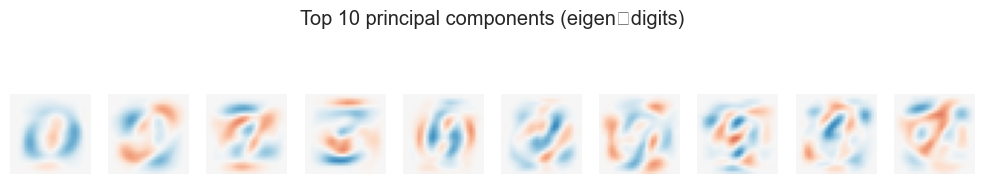

In [16]:
pcs = pca50.components_[:10]   # first 10 components
plt.figure(figsize=(10,2.2))
for i in range(10):
    ax = plt.subplot(1,10,i+1)
    plt.imshow(pcs[i].reshape(28,28), cmap='RdBu', vmin=-0.2, vmax=0.2)
    plt.axis('off')
plt.suptitle('Top 10 principal components (eigen‑digits)')
plt.tight_layout(); plt.show()

Find #components for 95% variance (set n_components=0.95), report that number and the reconstruction MSE.

In [17]:
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error

# 1. Initialize PCA with n_components=0.95
# This tells sklearn to choose the minimum number of components 
# needed to preserve 95% of the variance.
pca95 = PCA(n_components=0.95)

# 2. Fit on the training data
pca95.fit(Xtr)

# 3. Report the number of components found
n_components_95 = pca95.n_components_
print(f"Number of components for 95% variance: {n_components_95}")

# 4. Calculate Reconstruction MSE
# We project the test data down to the lower dimension...
Zte95 = pca95.transform(Xte)
# ...and then project it back to the original 784D space.
Xte_reconstructed = pca95.inverse_transform(Zte95)

# Calculate the Mean Squared Error between the original and reconstructed data
mse_95 = mean_squared_error(Xte, Xte_reconstructed)
print(f"Reconstruction MSE (Test Set): {mse_95:.4f}")


Number of components for 95% variance: 328
Reconstruction MSE (Test Set): 0.0770


Sweep k ∈ {10, 25, 50, 100, 200} and plot test accuracy vs k for Logistic Regression; discuss the speed/accuracy trade‑off.

k     | Accuracy   | Time (s)  
------------------------------


C:\Users\PRASAD\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


10    | 0.8035     | 2.7349


C:\Users\PRASAD\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


25    | 0.8784     | 3.3975


...

50    | 0.9016     | 4.5889


C:\Users\PRASAD\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


100   | 0.9140     | 9.0382


C:\Users\PRASAD\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


200   | 0.9199     | 13.8161


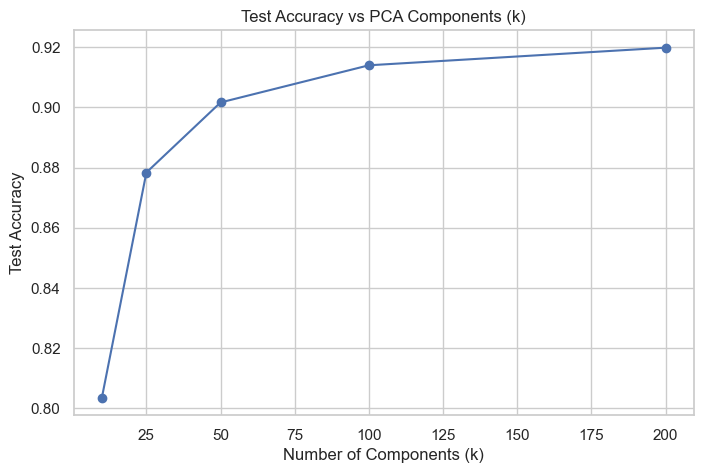

In [18]:
import time
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Define the values of k to sweep
k_values = [10, 25, 50, 100, 200]

accuracies = []
train_times = []

print(f"{'k':<5} | {'Accuracy':<10} | {'Time (s)':<10}")
print("-" * 30)

for k in k_values:
    # 1. Apply PCA
    pca = PCA(n_components=k)
    # Fit on training data only to prevent data leakage
    Ztr_k = pca.fit_transform(Xtr)
    Zte_k = pca.transform(Xte)
    
    # 2. Train Logistic Regression
    # We use a fixed solver and n_jobs=-1 for parallel processing
    clf = LogisticRegression(max_iter=1000, solver='lbfgs', n_jobs=-1)
    
    t0 = time.time()
    clf.fit(Ztr_k, ytr)
    t1 = time.time()
    
    # 3. Evaluate
    acc = accuracy_score(yte, clf.predict(Zte_k))
    
    # Store metrics
    accuracies.append(acc)
    train_times.append(t1 - t0)
    
    print(f"{k:<5} | {acc:.4f}     | {t1 - t0:.4f}")

# Plotting Test Accuracy vs k
plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, marker='o', linestyle='-', color='b', label='Accuracy')
plt.title('Test Accuracy vs PCA Components (k)')
plt.xlabel('Number of Components (k)')
plt.ylabel('Test Accuracy')
plt.grid(True)
plt.show()


Plot per‑class reconstruction MSE (group by digit label); which digits compress best/worst and why?

Digit  | MSE       
--------------------
0      | 0.2091
1      | 0.1666
2      | 0.7405
3      | 0.6951
4      | 0.2661
5      | 0.3953
6      | 0.6398
7      | 0.6342
8      | 0.3035
9      | 0.2962


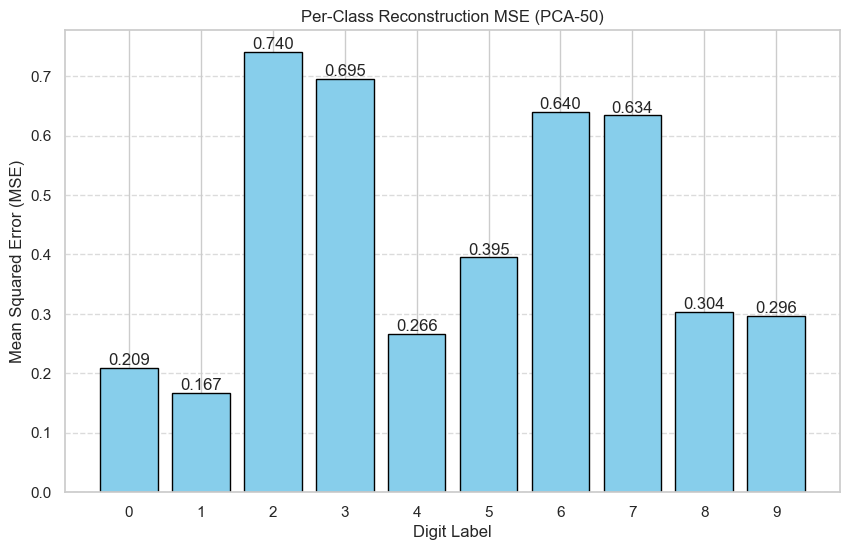

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# Ensure pca50, Xte, and yte are available from previous steps
digits = np.unique(yte)
mse_per_class = []

print(f"{'Digit':<6} | {'MSE':<10}")
print("-" * 20)

for digit in digits:
    # 1. Filter the test set for the specific digit
    mask = (yte == digit)
    X_class = Xte[mask]
    
    # 2. Transform (compress) and Inverse Transform (reconstruct)
    Z_class = pca50.transform(X_class)
    X_reconstructed = pca50.inverse_transform(Z_class)
    
    # 3. Calculate MSE for this specific class
    mse = mean_squared_error(X_class, X_reconstructed)
    mse_per_class.append(mse)
    
    print(f"{digit:<6} | {mse:.4f}")

# 4. Plotting the results
plt.figure(figsize=(10, 6))
bars = plt.bar(digits, mse_per_class, color='skyblue', edgecolor='black')

plt.xlabel('Digit Label')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Per-Class Reconstruction MSE (PCA-50)')
plt.xticks(digits)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add text labels above bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.3f}', ha='center', va='bottom')

plt.show()


Compare PCA‑2D vs t‑SNE‑2D (sklearn.manifold.TSNE) on a 10k subset for visualization— which separates digits better?

Running visualization on 10000 samples...
Running PCA...
PCA done in 0.30s
Running t-SNE (this may take a moment)...
t-SNE done in 91.56s


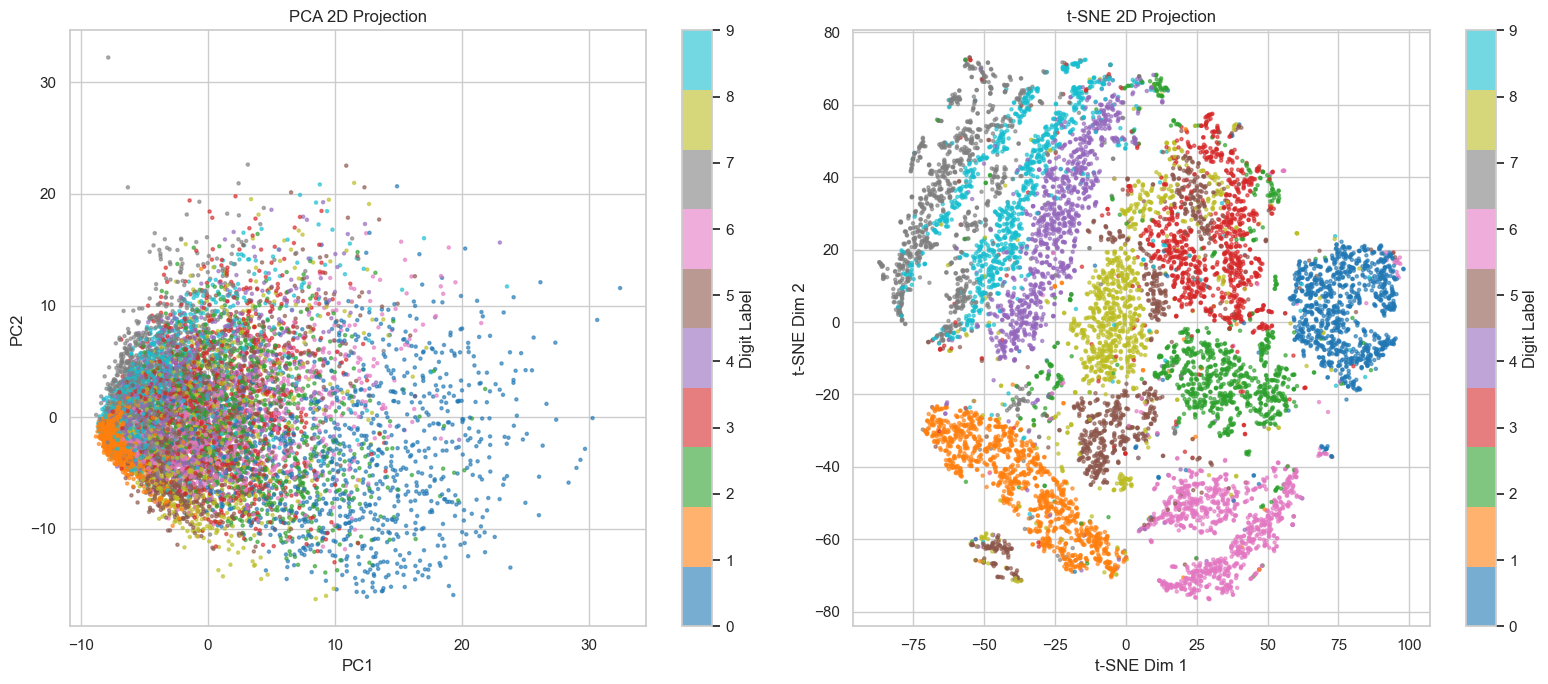

In [20]:
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# 1. Select a 10k subset for visualization
# t-SNE is slow on the full dataset, so we limit to 10,000 samples.
n_subset = 10000
X_viz = Xtr[:n_subset]
y_viz = ytr[:n_subset]

print(f"Running visualization on {n_subset} samples...")

# ---------------------------------------------------------
# 2. Run PCA (2D)
# ---------------------------------------------------------
print("Running PCA...")
t0 = time.time()
pca_2d = PCA(n_components=2)
Z_pca = pca_2d.fit_transform(X_viz)
print(f"PCA done in {time.time() - t0:.2f}s")

# ---------------------------------------------------------
# 3. Run t-SNE (2D)
# ---------------------------------------------------------
print("Running t-SNE (this may take a moment)...")
t0 = time.time()
# init='pca' usually helps t-SNE converge faster and more globally stable
tsne = TSNE(n_components=2, init='pca', learning_rate='auto', random_state=42, n_jobs=-1)
Z_tsne = tsne.fit_transform(X_viz)
print(f"t-SNE done in {time.time() - t0:.2f}s")

# ---------------------------------------------------------
# 4. Plotting Side-by-Side
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot PCA
scatter1 = axes[0].scatter(Z_pca[:, 0], Z_pca[:, 1], c=y_viz, cmap='tab10', alpha=0.6, s=5)
axes[0].set_title('PCA 2D Projection')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
fig.colorbar(scatter1, ax=axes[0], label='Digit Label')

# Plot t-SNE
scatter2 = axes[1].scatter(Z_tsne[:, 0], Z_tsne[:, 1], c=y_viz, cmap='tab10', alpha=0.6, s=5)
axes[1].set_title('t-SNE 2D Projection')
axes[1].set_xlabel('t-SNE Dim 1')
axes[1].set_ylabel('t-SNE Dim 2')
fig.colorbar(scatter2, ax=axes[1], label='Digit Label')

plt.tight_layout()
plt.show()
